Markdown

# D2C Customer Churn Intelligence - Part 1

## 1. Business Understanding

The objective of this project is to analyze customer behavior, identify churn risk factors, and provide business recommendations for improving customer retention.

## 2. Data Loading

## 3. Dataset Overview

## 4. Data Quality Audit

## 5. Exploratory Data Analysis

## 6. Churn Risk Hypotheses

## 7. Business Recommendations

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [5]:
from google.colab import files

uploaded = files.upload()

Saving orders.csv to orders (1).csv
Saving support_tickets.csv to support_tickets (1).csv
Saving churn_labels.csv to churn_labels (1).csv
Saving web_events_snapshot.csv to web_events_snapshot (1).csv
Saving intervention_history.csv to intervention_history (1).csv
Saving DATA_DICTIONARY.md to DATA_DICTIONARY (1).md
Saving customers.csv to customers (2).csv


In [6]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
tickets = pd.read_csv("support_tickets.csv")
web = pd.read_csv("web_events_snapshot.csv")
labels = pd.read_csv("churn_labels.csv")
campaigns = pd.read_csv("intervention_history.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [7]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Tickets:", tickets.shape)
print("Web:", web.shape)
print("Labels:", labels.shape)
print("Campaigns:", campaigns.shape)

Customers: (2400, 9)
Orders: (10009, 10)
Tickets: (1921, 8)
Web: (2400, 10)
Labels: (2400, 4)
Campaigns: (2400, 5)


### Dataset Overview

The D2C Customer Churn dataset consists of six interconnected datasets that capture different aspects of customer behavior and business operations. Together, these datasets provide a comprehensive view of customer demographics, purchase history, support interactions, online engagement, marketing interventions, and churn outcomes.

The analysis is performed at the customer level using `customer_id` as the primary key across all datasets.

The datasets included in this project are:

- **Customers Dataset:** Contains customer demographic and acquisition information such as age group, city tier, acquisition channel, loyalty tier, and marketing consent.
- **Orders Dataset:** Contains transaction-level information including purchase dates, order values, discounts, returns, delivery performance, and customer ratings.
- **Support Tickets Dataset:** Captures customer service interactions, issue types, resolution times, sentiment scores, and ticket reopening information.
- **Web Activity Dataset:** Provides customer engagement metrics such as sessions, product views, cart additions, wishlist activity, and campaign interactions during the 30 days prior to the snapshot date.
- **Churn Labels Dataset:** Contains the target variable indicating whether a customer churned within the 60-day prediction window, along with train, validation, and test split assignments.
- **Intervention History Dataset:** Records the most recent retention campaign delivered to each customer before the snapshot date.

In [8]:
datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web": web,
    "labels": labels,
    "campaigns": campaigns
}

overview = []

for name, df in datasets.items():
    overview.append([
        name,
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum()
    ])

overview_df = pd.DataFrame(
    overview,
    columns=[
        "Dataset",
        "Rows",
        "Columns",
        "Missing Values"
    ]
)

overview_df

,Dataset,Rows,Columns,Missing Values
0,customers,2400,9,1787
1,orders,10009,10,80
2,tickets,1921,8,0
3,web,2400,10,0
4,labels,2400,4,0
5,campaigns,2400,5,0


### Initial Observations

- The project consists of six datasets covering customer demographics, purchase behavior, support interactions, digital engagement, churn outcomes, and marketing interventions.
- The orders dataset contains the highest number of records because it stores transaction-level information.
- The customers dataset contains the largest number of missing values and requires further investigation.
- The orders dataset contains a small number of missing values that should be examined before modeling.
- The remaining datasets appear complete and suitable for downstream analysis.

## 4. Data Quality Audit

The purpose of this audit is to identify data quality issues that may affect analysis and modeling performance. The audit focuses on missing values, duplicate records, invalid values, and potential data leakage risks.

In [9]:
for name, df in datasets.items():

    print("\n" + "="*50)
    print(name.upper())

    missing = (
        df.isnull()
        .sum()
        .sort_values(ascending=False)
    )

    print(missing[missing > 0])


CUSTOMERS
loyalty_tier    1386
skin_type        401
dtype: int64

ORDERS
rating    80
dtype: int64

TICKETS
Series([], dtype: int64)

WEB
Series([], dtype: int64)

LABELS
Series([], dtype: int64)

CAMPAIGNS
Series([], dtype: int64)


### Missing Value Findings

The missing value analysis revealed three columns with incomplete information.

#### Customers Dataset
- The `loyalty_tier` column contains 1,386 missing values, representing a substantial portion of customer records.
- The `skin_type` column contains 401 missing values.

#### Orders Dataset
- The `rating` column contains 80 missing values. This is expected because some customers may not have submitted product ratings after purchase.

#### Other Datasets
- The support tickets, web activity, churn labels, and campaign datasets do not contain missing values.

#### Business Impact
Missing values in loyalty-related attributes may affect customer segmentation and churn analysis. Appropriate imputation strategies will be considered during feature engineering while preserving business meaning.

In [10]:
orders[
    orders["order_id"].str.contains("_DUP", na=False)
]

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0
3708,ORD008836_DUP,CUST00875,2025-10-23,Baby Care,2,711.20,0.19,6,0,5.0
4799,ORD003897_DUP,CUST01140,2025-04-14,Baby Care,2,769.96,0.25,5,0,4.0
5633,ORD004577_DUP,CUST01335,2025-02-12,Wellness,1,533.07,0.28,3,0,3.0
6687,ORD005451_DUP,CUST01601,2024-11-07,Makeup,2,1160.41,0.32,4,0,5.0
6780,ORD005529_DUP,CUST01621,2024-08-12,Baby Care,1,339.33,0.15,3,0,1.0


In [11]:
orders[
    orders["order_id"].str.contains("_DUP", na=False)
].shape

(12, 10)

### Duplicate Record Analysis

The orders dataset contains 12 records with order IDs ending in "_DUP". These records appear to be intentionally inserted duplicate-like transactions designed to simulate real-world data quality issues.

#### Findings
- A total of 12 duplicate-like order records were identified.
- These records are distinguishable through the "_DUP" suffix in the order_id field.
- The presence of such records highlights the importance of validating transaction data before performing customer-level aggregation and feature engineering.

#### Business Impact
Duplicate transactions can inflate revenue, purchase frequency, and customer activity metrics if not properly identified and handled. Therefore, duplicate checks should be incorporated into the data preparation workflow.

In [12]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

snapshot_date = pd.Timestamp(
    "2025-09-30"
)

post_snapshot_orders = orders[
    orders["order_date"] > snapshot_date
]

post_snapshot_orders.shape

(1872, 10)

### Data Leakage Analysis

A snapshot date of **30 September 2025** was used as the reference point for churn prediction.

The analysis identified **1,872 order records occurring after the snapshot date**. These records belong to the future period relative to the prediction date and therefore must not be used during feature engineering or customer segmentation.

#### Findings
- Total post-snapshot orders identified: **1,872**
- These records contain information that would not have been available at prediction time.
- Including these records would introduce target leakage and artificially improve model performance.

#### Business Impact
Data leakage can lead to overly optimistic model results that fail in real-world deployment. To ensure a realistic churn prediction framework, only information available on or before the snapshot date will be used in subsequent project stages.

In [13]:
orders_pre = orders[
    orders["order_date"] <= snapshot_date
]

print("Orders before snapshot:", orders_pre.shape)
print("Orders after snapshot:", post_snapshot_orders.shape)

Orders before snapshot: (8137, 10)
Orders after snapshot: (1872, 10)


In [14]:
customers["customer_id"].nunique()

2400

In [15]:
labels["customer_id"].nunique()

2400

In [16]:
web["customer_id"].nunique()

2400

In [17]:
campaigns["customer_id"].nunique()

2400

In [18]:
master = (
    customers
    .merge(labels, on="customer_id")
    .merge(web, on="customer_id")
    .merge(campaigns, on="customer_id")
)

master.shape

(2400, 25)

## 5. Exploratory Data Analysis

The objective of this section is to identify patterns associated with customer churn and generate business hypotheses that can guide retention strategies.

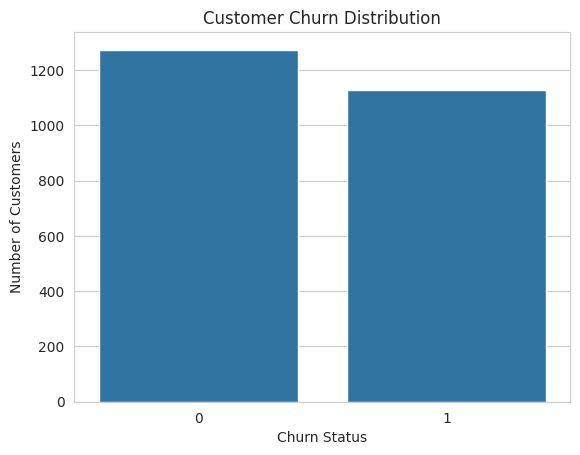

In [19]:
sns.countplot(
    data=labels,
    x="churn_next_60d"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

In [20]:
churn_rate = labels["churn_next_60d"].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 46.96%


### Churn Distribution Findings

The customer base exhibits a churn rate of approximately 47% (46.96%), indicating a relatively balanced classification problem.

A balanced target distribution is beneficial for predictive modeling because it reduces the need for aggressive class balancing techniques and allows evaluation metrics such as precision, recall, F1-score, and ROC-AUC to be interpreted more reliably.

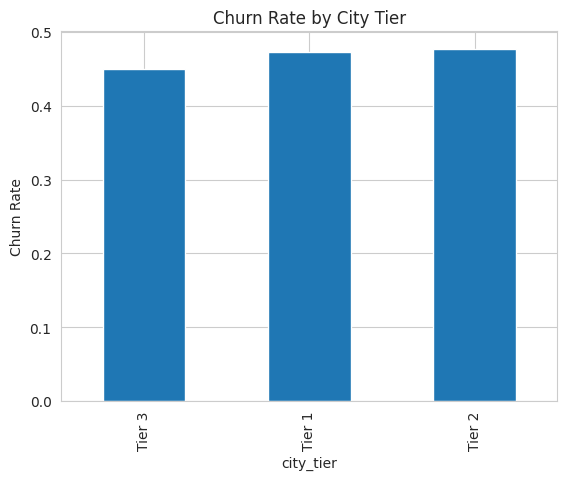

In [21]:
city_churn = (
    master
    .groupby("city_tier")["churn_next_60d"]
    .mean()
    .sort_values()
)

city_churn.plot(kind="bar")

plt.title("Churn Rate by City Tier")
plt.ylabel("Churn Rate")
plt.show()

### City Tier Analysis

Customer churn rates are relatively similar across all city tiers, ranging between 45% and 48%.

Tier 3 cities exhibit the lowest churn rate, while Tier 1 and Tier 2 cities show slightly higher churn levels. This suggests that geographical location alone is not a major driver of customer attrition in this dataset.

Additional behavioral and transactional variables should be investigated to identify stronger churn predictors.

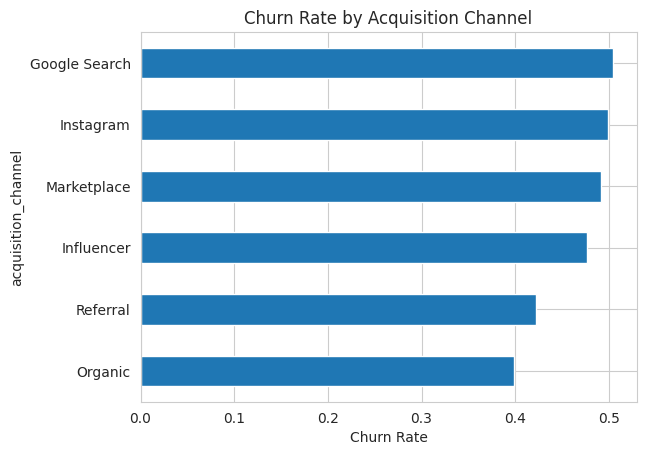

In [22]:
channel_churn = (
    master
    .groupby("acquisition_channel")["churn_next_60d"]
    .mean()
    .sort_values()
)

channel_churn.plot(
    kind="barh"
)

plt.title("Churn Rate by Acquisition Channel")
plt.xlabel("Churn Rate")
plt.show()

### Acquisition Channel Analysis

Customer acquisition channel appears to influence churn behavior.

Customers acquired through Google Search and Instagram exhibit the highest churn rates, approaching 50%. In contrast, customers acquired through Organic and Referral channels demonstrate relatively lower churn rates.

This finding suggests that customers obtained through paid or promotional channels may have lower long-term engagement compared to customers who discover the brand organically or through referrals.

##6.Churn Risk Hypotheses

Based on the exploratory analysis and business understanding of the D2C customer lifecycle, the following churn hypotheses will be investigated in subsequent modeling phases:

### Hypothesis 1
Customers with low website engagement are more likely to churn.

### Hypothesis 2
Customers who have not purchased recently are at higher risk of churn.

### Hypothesis 3
Customers who submit support tickets with negative sentiment are more likely to churn.

### Hypothesis 4
Customers acquired through paid marketing channels have higher churn rates than organically acquired customers.

### Hypothesis 5
Customers with lower loyalty program engagement are more likely to churn.

## Conclusion

This analysis examined customer demographics, transaction history, support interactions, website engagement, marketing exposure, and churn outcomes.

The data quality audit identified missing values in customer attributes, minor missing ratings within order records, duplicate order identifiers, and several data quality considerations that should be addressed before predictive modeling.

Exploratory analysis revealed an overall churn rate of 46.96%, indicating a balanced target variable suitable for machine learning applications. Acquisition channel demonstrated meaningful variation in churn behavior, while city tier showed limited influence.

The identified churn hypotheses provide a foundation for feature engineering and predictive modeling in subsequent project phases.